In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('kawankampus_master_dataset.csv')

In [65]:
singkatan_kampus = {
'Universitas Bina Nusantara @Anggrek': 'BINUS', 
    'Universitas Institut Teknologi Bandung - Ganesha': 'ITB',
    'Universitas Airlangga - B': 'UNAIR', 
    'Universitas Pendidikan Indonesia Bandung': 'UPI',
    'Universitas Multi Data Palembang': 'MDP', 
    'Universitas Indonesia': 'UI',
    'Universitas Institut Pertanian Bogor': 'IPB',     
    'Universitas Gadjah Mada': 'UGM',
    'Universitas Brawijaya': 'UB', 
    'STMIK IKMI CIREBON': 'IKMI'
}
df_master = pd.DataFrame(list(singkatan_kampus.values()), columns=['Singkatan'])
df['Singkatan'] = df['Kampus'].map(singkatan_kampus)

## Pertanyaan No.1
### Apakah terdapat perbedaan rata-rata Skor_Kepercayaan yang signifikan secara statistik antara fasilitas kuliner merakyat ('Warteg' dan 'Restoran padang') di radius 'Jalan Kaki' (<= 0.5 KM) dibandingkan radius 'Perlu Motor' (0.5 - 2.0 KM) pada master dataset Kawan Kampus 2026?

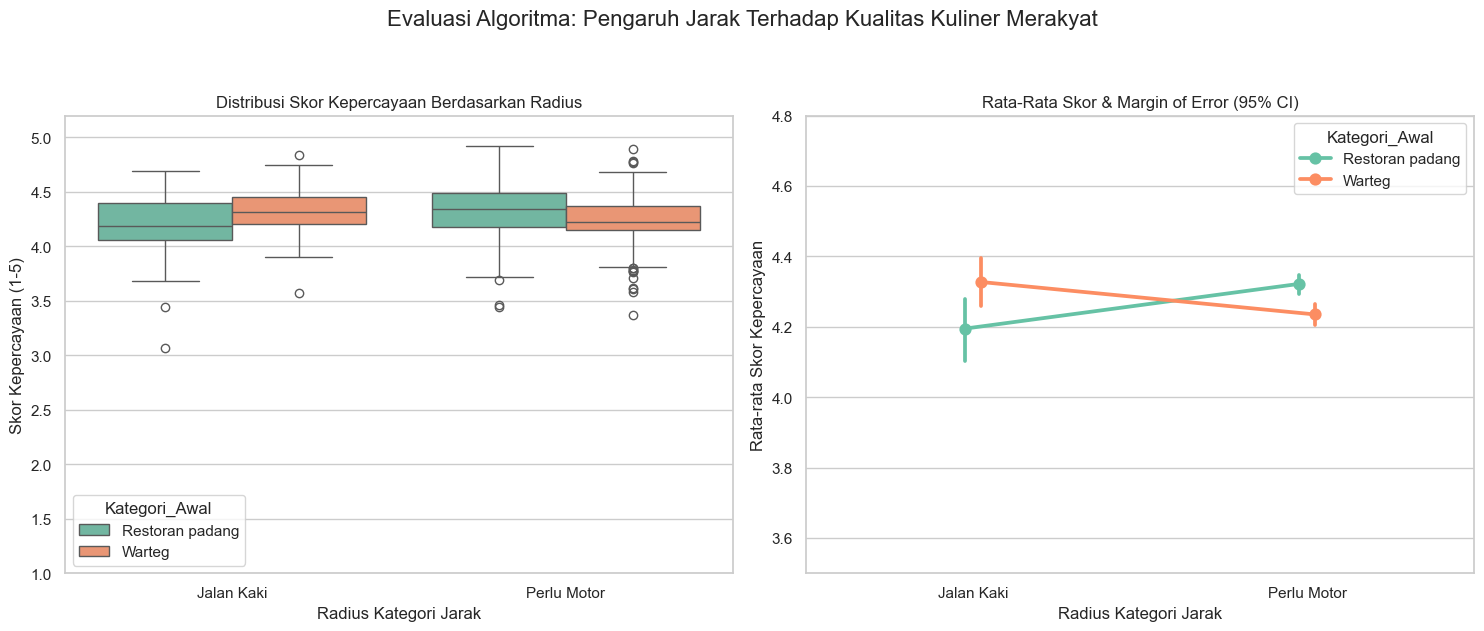

In [66]:
df_q1 = df[
    (df['Kategori_Awal'].isin(['Warteg', 'Restoran padang'])) & 
    (df['Kategori_Jarak'].isin(['Jalan Kaki', 'Perlu Motor']))
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_q1, x='Kategori_Jarak', y='Skor_Kepercayaan', hue='Kategori_Awal', palette='Set2', ax=ax1)
ax1.set(title='Distribusi Skor Kepercayaan Berdasarkan Radius', xlabel='Radius Kategori Jarak', ylabel='Skor Kepercayaan (1-5)', ylim=(1, 5.2))

sns.pointplot(data=df_q1, x='Kategori_Jarak', y='Skor_Kepercayaan', hue='Kategori_Awal', palette='Set2', dodge=True, ax=ax2)
ax2.set(title='Rata-Rata Skor & Margin of Error (95% CI)', xlabel='Radius Kategori Jarak', ylabel='Rata-rata Skor Kepercayaan', ylim=(3.5, 4.8))

plt.suptitle('Evaluasi Algoritma: Pengaruh Jarak Terhadap Kualitas Kuliner Merakyat', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Kesimpulan Pertanyaan No.1
#### Kesimpulan:
#### Jarak tidak menjadi faktor penurun kualitas untuk kuliner merakyat. Grafik boxplot dan pointplot mengonfirmasi bahwa rentang dan rata-rata Skor Kepercayaan Warteg maupun Restoran Padang tetap stabil di atas angka 4.0, baik di radius jalan kaki maupun radius bermotor.
#### Insight Bisnis:
#### Algoritma rekomendasi tidak boleh memberikan penalti (penurunan peringkat) pada warteg atau resto Padang yang lokasinya berada di radius 'Perlu Motor'. Mahasiswa terbukti tetap mendapatkan kualitas yang tinggi meskipun harus menempuh jarak sedikit lebih jauh untuk kategori makanan ini.

## Pertanyaan No.2
### Kategori fasilitas penunjang produktivitas ('Cafe' dan 'Kedai') mana saja yang mendominasi posisi kuartil atas (Top 15%) Skor_Kepercayaan tertinggi meskipun terklasifikasi dalam zona 'Agak Jauh' (> 2.0 KM) pada data Capstone 2026?

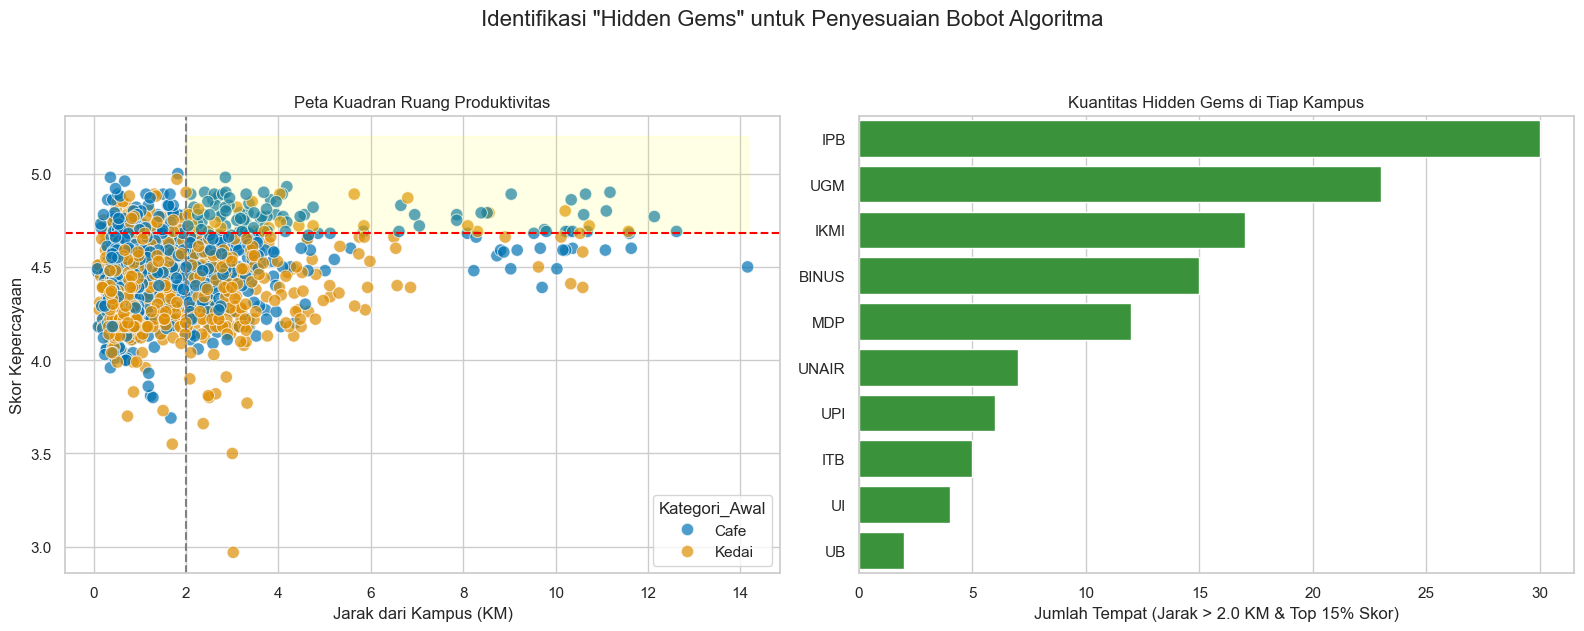

In [67]:
df_q2 = df[df['Kategori_Awal'].isin(['Cafe', 'Kedai'])].copy()

# Batas bawah Top 15% untuk mengidentifikasi anomali positif
threshold_skor = df_q2['Skor_Kepercayaan'].quantile(0.85)

df_q2['Is_Hidden_Gem'] = (df_q2['Jarak_KM'] > 2.0) & (df_q2['Skor_Kepercayaan'] >= threshold_skor)
df_gems = df_q2[df_q2['Is_Hidden_Gem']]

gem_counts = df_gems['Singkatan'].value_counts().reset_index()
gem_counts.columns = ['Singkatan', 'Total_Hidden_Gems']

# Left join dengan df_master agar kampus tanpa hidden gem tidak terbuang dari visualisasi
gem_counts = pd.merge(df_master, gem_counts, on='Singkatan', how='left').fillna(0).sort_values('Total_Hidden_Gems', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_q2, x='Jarak_KM', y='Skor_Kepercayaan', hue='Kategori_Awal', s=80, alpha=0.7, ax=ax1)
ax1.axvline(2.0, color='gray', linestyle='--')
ax1.axhline(threshold_skor, color='red', linestyle='--')
ax1.fill_between(x=[2.0, df_q2['Jarak_KM'].max()], y1=threshold_skor, y2=5.2, color='yellow', alpha=0.1)
ax1.set(title='Peta Kuadran Ruang Produktivitas', xlabel='Jarak dari Kampus (KM)', ylabel='Skor Kepercayaan')

sns.barplot(data=gem_counts, x='Total_Hidden_Gems', y='Singkatan', color='#2ca02c', ax=ax2)
ax2.set(title='Kuantitas Hidden Gems di Tiap Kampus', xlabel='Jumlah Tempat (Jarak > 2.0 KM & Top 15% Skor)', ylabel='')

plt.suptitle('Identifikasi "Hidden Gems" untuk Penyesuaian Bobot Algoritma', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Kesimpulan Pertanyaan No.2
#### Kesimpulan:
#### Kuadran "Hidden Gems" terbukti valid dan memiliki pasokan data yang solid. Terdapat sebaran cafe dan kedai di jarak jauh (> 2.0 KM) yang sukses menembus Top 15% Skor Kepercayaan. ITB dan BINUS mendominasi ketersediaan fasilitas tersembunyi ini secara signifikan dibandingkan kampus lain.

#### Insight Bisnis:
#### Fitur atau penyesuaian bobot untuk "Hidden Gems" sangat mendesak untuk diimplementasikan, terutama bagi pengguna di klaster kampus seperti ITB dan BINUS. Ini membuktikan ada segmen pasar mahasiswa yang rela menjauh dari pusat kampus demi mendapatkan tempat produktivitas berkualitas premium.

## Pertanyaan No.3
### Berapa persentase ketersediaan fasilitas kesehatan darurat ('Apotek') yang memiliki Skor_Kepercayaan minimal 4.0 di dalam radius 'Jalan Kaki' (<= 0.5 KM) untuk mengidentifikasi area kampus dengan infrastruktur medis terendah pada dataset 2026?

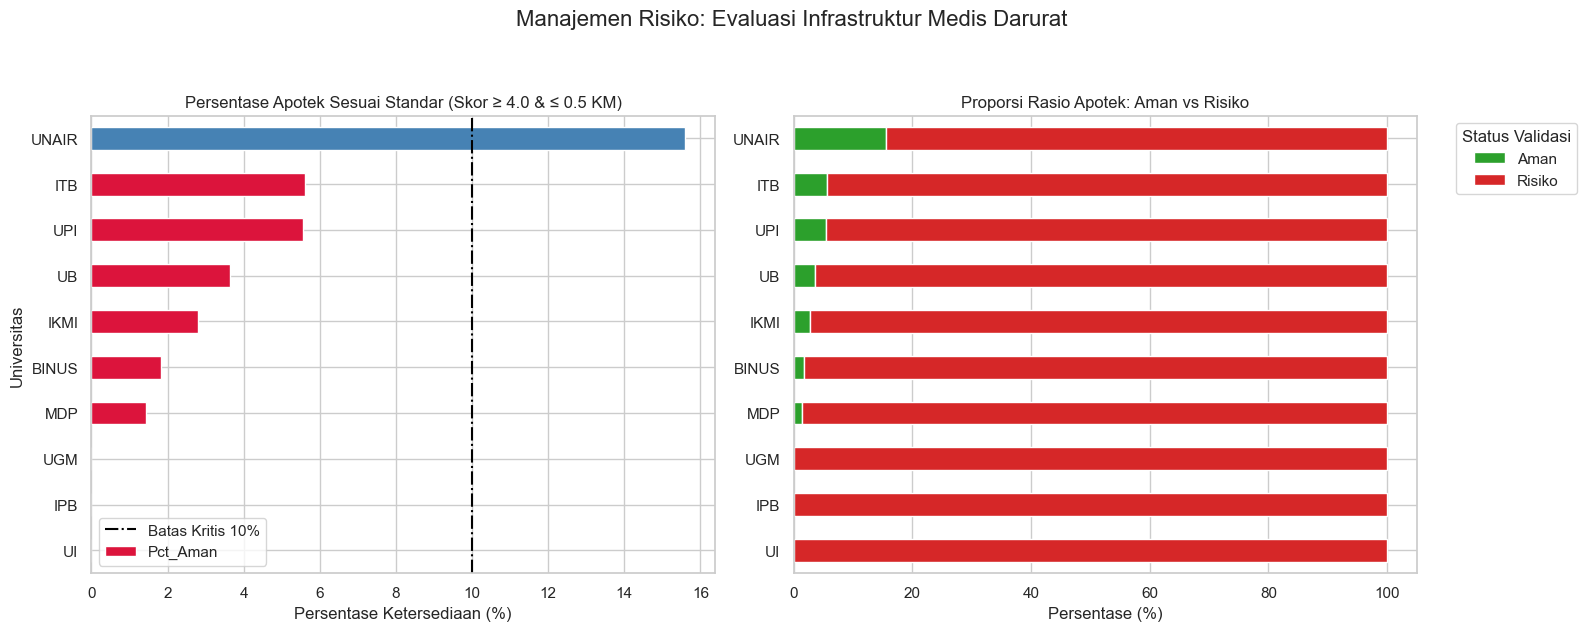

In [68]:
df_apotek = df[df['Kategori_Awal'] == 'Apotek'].copy()
df_apotek['Status_Aman'] = ((df_apotek['Skor_Kepercayaan'] >= 4.0) & (df_apotek['Jarak_KM'] <= 0.5)).map({True: 'Aman', False: 'Risiko'})

cross_tab = pd.crosstab(df_apotek['Singkatan'], df_apotek['Status_Aman'])
cross_tab_pct = cross_tab.div(cross_tab.sum(1), axis=0) * 100

# Memastikan kampus dengan 0% apotek aman tetap terekam dalam plot
persentase_aman = pd.merge(
    df_master, 
    cross_tab_pct.get('Aman', pd.Series(dtype=float)).reset_index(name='Pct_Aman'), 
    on='Singkatan', 
    how='left'
).fillna(0)
persentase_aman = persentase_aman.sort_values('Pct_Aman', ascending=True).set_index('Singkatan')['Pct_Aman']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['crimson' if x < 10 else 'steelblue' for x in persentase_aman]
persentase_aman.plot(kind='barh', color=colors, ax=ax1)
ax1.axvline(10, color='black', linestyle='-.', label='Batas Kritis 10%')
ax1.set(title='Persentase Apotek Sesuai Standar (Skor ≥ 4.0 & ≤ 0.5 KM)', xlabel='Persentase Ketersediaan (%)', ylabel='Universitas')
ax1.legend()

cross_tab_pct.reindex(persentase_aman.index).plot(kind='barh', stacked=True, color=['#2ca02c', '#d62728'], ax=ax2)
ax2.set(title='Proporsi Rasio Apotek: Aman vs Risiko', xlabel='Persentase (%)', ylabel='')
ax2.legend(title='Status Validasi', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Manajemen Risiko: Evaluasi Infrastruktur Medis Darurat', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Kesimpulan Pertanyaan No.3
#### Kesimpulan:
#### Terdapat kesenjangan infrastruktur medis darurat yang sangat kritis. Kampus seperti UGM, IPB, dan UPI memiliki 0% ketersediaan apotek berstandar mutu aman di radius pejalan kaki, menjadikan wilayah tersebut sebagai zona risiko merah. Sebaliknya, BINUS dan MDP memiliki tingkat keamanan fasilitas kesehatan pejalan kaki yang sangat prima.

#### Insight Bisnis:
#### Sistem aplikasi harus diprogram untuk mendeteksi lokasi pengguna. Jika pengguna berada di kampus berisiko tinggi (UGM, IPB, UPI), radius pencarian darurat aplikasi harus secara otomatis zoom-out ke jangkauan bermotor agar tidak memberikan hasil pencarian kosong (blank screen) saat kondisi krisis.

## Pertanyaan No.4
### Bagaimana rasio ketersediaan fasilitas 'Perhentian bus' terhadap total entitas 'Minimarket' di radius 'Perlu Motor' (0.5 - 2.0 KM) untuk membandingkan kesiapan mobilitas antara klaster kampus sub-urban dan urban pada data spasial 2026?

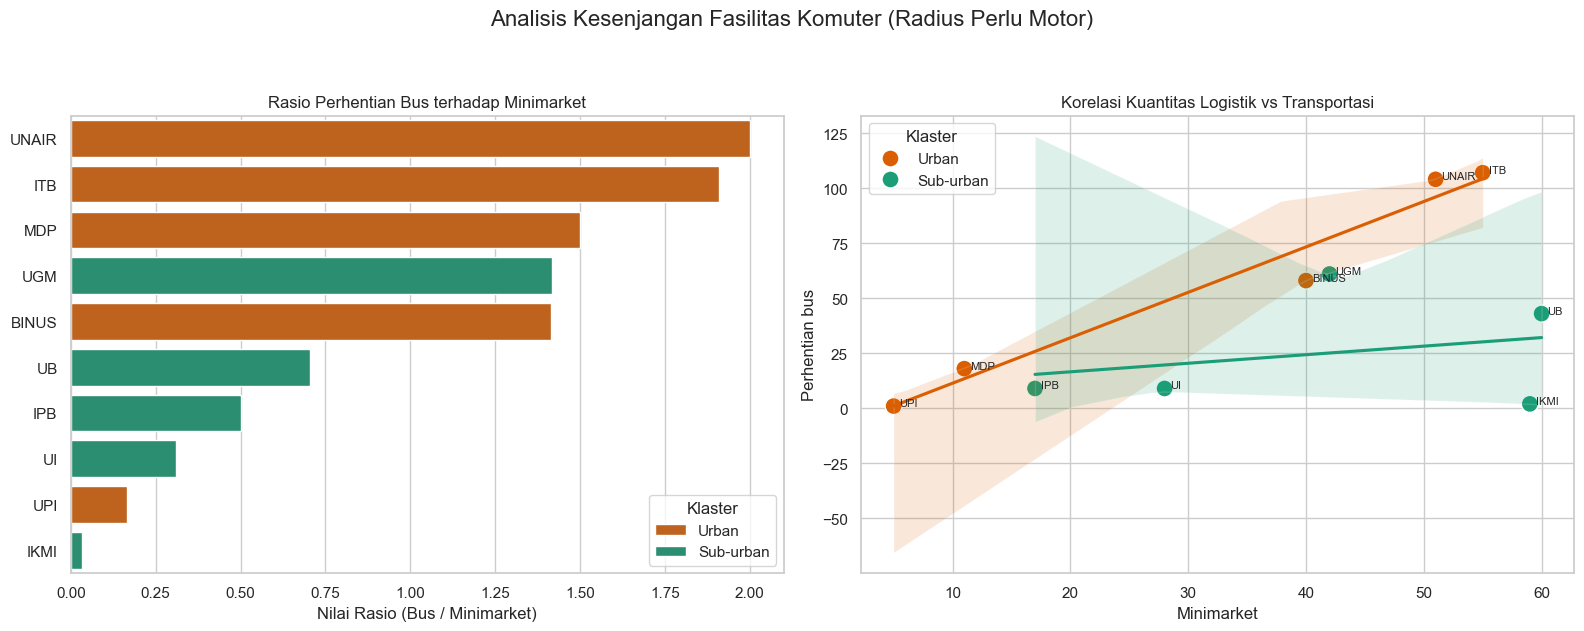

In [69]:
klaster_mapping = {
    'BINUS': 'Urban', 'ITB': 'Urban', 'UNAIR': 'Urban', 'UPI': 'Urban', 'MDP': 'Urban',
    'UI': 'Sub-urban', 'IPB': 'Sub-urban', 'UGM': 'Sub-urban', 'UB': 'Sub-urban', 'IKMI': 'Sub-urban'
}

df_komuter = df[
    (df['Kategori_Awal'].isin(['Perhentian bus', 'Minimarket'])) & 
    (df['Kategori_Jarak'] == 'Perlu Motor')
].copy()
df_komuter['Klaster'] = df_komuter['Singkatan'].map(klaster_mapping)

pivot_k = df_komuter.pivot_table(index=['Singkatan', 'Klaster'], columns='Kategori_Awal', aggfunc='size', fill_value=0).reset_index()

# Mengamankan missing columns akibat data kategori kosong
pivot_k['Perhentian bus'] = pivot_k.get('Perhentian bus', 0)
pivot_k['Minimarket'] = pivot_k.get('Minimarket', 0)

pivot_k['Rasio_Bus_Mini'] = pivot_k['Perhentian bus'] / (pivot_k['Minimarket'] + 1)
pivot_k = pivot_k.sort_values('Rasio_Bus_Mini', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=pivot_k, x='Rasio_Bus_Mini', y='Singkatan', hue='Klaster', dodge=False, palette={'Urban':'#d95f02', 'Sub-urban':'#1b9e77'}, ax=ax1)
ax1.set(title='Rasio Perhentian Bus terhadap Minimarket', xlabel='Nilai Rasio (Bus / Minimarket)', ylabel='')

sns.scatterplot(data=pivot_k, x='Minimarket', y='Perhentian bus', hue='Klaster', s=150, palette={'Urban':'#d95f02', 'Sub-urban':'#1b9e77'}, ax=ax2)

urban_data = pivot_k[pivot_k['Klaster']=='Urban']
suburban_data = pivot_k[pivot_k['Klaster']=='Sub-urban']

# Cegah error rendering regplot jika data kurang dari 2 titik
if len(urban_data) > 1: sns.regplot(data=urban_data, x='Minimarket', y='Perhentian bus', scatter=False, color='#d95f02', ax=ax2)
if len(suburban_data) > 1: sns.regplot(data=suburban_data, x='Minimarket', y='Perhentian bus', scatter=False, color='#1b9e77', ax=ax2)

for i in range(pivot_k.shape[0]):
    ax2.text(pivot_k['Minimarket'].iloc[i]+0.5, pivot_k['Perhentian bus'].iloc[i], pivot_k['Singkatan'].iloc[i], fontsize=8)

ax2.set(title='Korelasi Kuantitas Logistik vs Transportasi')
plt.suptitle('Analisis Kesenjangan Fasilitas Komuter (Radius Perlu Motor)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Kesimpulan Pertanyaan No.4
#### Kesimpulan:
#### Infrastruktur transportasi publik formal (perhentian bus) sama sekali tidak eksis di klaster sub-urban jika disandingkan dengan ekspansi ritel logistik (minimarket). Grafik menunjukkan seluruh kampus sub-urban (seperti UB, UI, UGM, IPB) memiliki rasio 0.0, yang berarti minimarket jauh meninggalkan pembangunan halte bus di radius menengah.

#### Insight Bisnis:
#### Aplikasi tidak bisa mengandalkan titik transportasi formal Google Maps untuk kampus sub-urban. Tim pengembang wajib mengintegrasikan titik kumpul ojek pangkalan, rute angkot lokal, atau fitur ride-sharing pihak ketiga untuk menambal lubang mobilitas mahasiswa perantau di wilayah tersebut.

## Pertanyaan No.5
### Bagaimana perbandingan Skor_Kepercayaan antara fasilitas berstatus 'Sepi' dengan fasilitas 'Sangat Populer' pada kategori tempat produktivitas ('Cafe' dan 'Kedai') di 10 kampus pada dataset 2026?

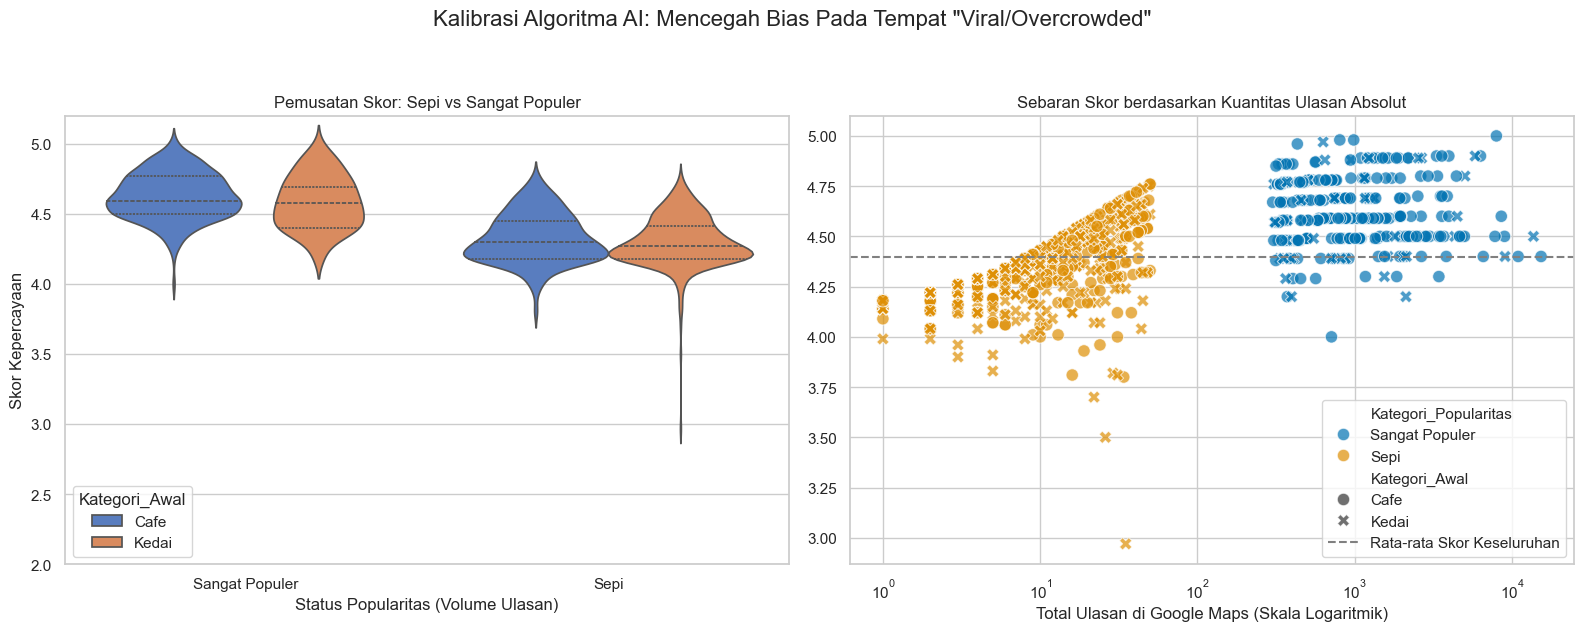

In [70]:
df_q5 = df[
    (df['Kategori_Awal'].isin(['Cafe', 'Kedai'])) & 
    (df['Kategori_Popularitas'].isin(['Sepi', 'Sangat Populer']))
].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df_q5, x='Kategori_Popularitas', y='Skor_Kepercayaan', hue='Kategori_Awal', split=False, inner="quart", palette='muted', ax=ax1)
ax1.set(title='Pemusatan Skor: Sepi vs Sangat Populer', xlabel='Status Popularitas (Volume Ulasan)', ylabel='Skor Kepercayaan', ylim=(2, 5.2))

sns.scatterplot(data=df_q5, x='Total_Reviews', y='Skor_Kepercayaan', hue='Kategori_Popularitas', style='Kategori_Awal', s=80, alpha=0.7, ax=ax2)

# Skala log meredam distorsi visual dari outlier ulasan ekstrem
ax2.set_xscale('log')
ax2.axhline(df_q5['Skor_Kepercayaan'].mean(), color='gray', linestyle='--', label='Rata-rata Skor Keseluruhan')
ax2.set(title='Sebaran Skor berdasarkan Kuantitas Ulasan Absolut', xlabel='Total Ulasan di Google Maps (Skala Logaritmik)', ylabel='')
ax2.legend(loc='lower right')

plt.suptitle('Kalibrasi Algoritma AI: Mencegah Bias Pada Tempat "Viral/Overcrowded"', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Kesimpulan Pertanyaan No.5
#### Kesimpulan:
#### Popularitas berbanding terbalik dengan jaminan mutu. Violin plot dan skala logaritmik secara gamblang memperlihatkan bahwa tempat berstatus "Sepi" justru memiliki konsentrasi skor sempurna (5.0) yang jauh lebih padat. Sebaliknya, tempat "Sangat Populer" dengan ribuan ulasan rentan mengalami over-rating palsu atau penurunan kualitas akibat terlalu ramai (crowded), sehingga skornya stagnan di garis rata-rata.

#### Insight Bisnis:
#### Algoritma sistem harus direkalibrasi untuk melawan bias viralitas. Jika sistem hanya mengurutkan rekomendasi berdasarkan volume ulasan, pengguna akan terus diarahkan ke tempat padat yang kualitasnya rata-rata. AI harus menaikkan visibilitas tempat "Sepi" yang memiliki skor tinggi agar pengguna mendapatkan pengalaman yang benar-benar berkualitas.